In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

DATA_DIR = Path('../../data/raw/markets')
print('Loading resolved markets...')

Loading resolved markets...


In [2]:
with open(DATA_DIR / 'markets_resolved_flat_20260305_163356.json') as f:
    resolved_raw = json.load(f)

print(f'Total resolved markets: {len(resolved_raw):,}')

df = pd.DataFrame(resolved_raw)
print(f'Columns: {len(df.columns)}')
print(f'\nKey columns:')
for col in ['question', 'volume', 'outcomePrices', 'outcomes', 'closed',
            'startDate', 'endDate', 'closedTime', 'negRisk', '_event_id']:
    if col in df.columns:
        non_null = df[col].notna().sum()
        print(f'  {col}: {non_null:,} non-null ({non_null/len(df)*100:.1f}%)')

Total resolved markets: 521,024


Columns: 140

Key columns:
  question: 521,024 non-null (100.0%)
  volume: 494,400 non-null (94.9%)
  outcomePrices: 520,598 non-null (99.9%)
  outcomes: 521,024 non-null (100.0%)
  closed: 521,024 non-null (100.0%)
  startDate: 516,764 non-null (99.2%)
  endDate: 519,717 non-null (99.7%)
  closedTime: 520,255 non-null (99.9%)
  negRisk: 512,064 non-null (98.3%)


  _event_id: 521,024 non-null (100.0%)


In [3]:
def safe_json_parse(val, default=None):
    if default is None: default = []
    if isinstance(val, str):
        try: return json.loads(val)
        except (json.JSONDecodeError, TypeError): return default
    if isinstance(val, (list, dict)): return val
    return default

def parse_prices(x):
    parsed = safe_json_parse(x, [])
    if not isinstance(parsed, list): return []
    try: return [float(p) for p in parsed]
    except (ValueError, TypeError): return []

df['_prices'] = df['outcomePrices'].apply(parse_prices)
df['_yes_price'] = df['_prices'].apply(lambda x: x[0] if len(x) >= 1 else np.nan)

df['_volume'] = pd.to_numeric(df.get('volume', pd.Series(dtype=float)), errors='coerce').fillna(0)
df['_lastTradePrice'] = pd.to_numeric(df.get('lastTradePrice', pd.Series(dtype=float)), errors='coerce')
df['_1d_change'] = pd.to_numeric(df.get('oneDayPriceChange', pd.Series(dtype=float)), errors='coerce')
df['_1w_change'] = pd.to_numeric(df.get('oneWeekPriceChange', pd.Series(dtype=float)), errors='coerce')
df['_1m_change'] = pd.to_numeric(df.get('oneMonthPriceChange', pd.Series(dtype=float)), errors='coerce')
df['_bestBid'] = pd.to_numeric(df.get('bestBid', pd.Series(dtype=float)), errors='coerce')
df['_bestAsk'] = pd.to_numeric(df.get('bestAsk', pd.Series(dtype=float)), errors='coerce')
df['_spread'] = df['_bestAsk'] - df['_bestBid']

for col in ['startDate', 'endDate', 'closedTime', 'createdAt']:
    if col in df.columns:
        df[f'_{col}'] = pd.to_datetime(df[col], errors='coerce', utc=True)

def get_outcome(yes_price):
    if pd.isna(yes_price):
        return 'unknown'
    if yes_price >= 0.99:
        return 'YES'
    elif yes_price <= 0.01:
        return 'NO'
    else:
        return 'unresolved'

df['_outcome'] = df['_yes_price'].apply(get_outcome)

df['_price_1m_ago'] = df['_lastTradePrice'] - df['_1m_change']
df['_price_1w_ago'] = df['_lastTradePrice'] - df['_1w_change']

print(f'Outcomes:\n{df["_outcome"].value_counts()}')
print(f'\nVolume stats:')
print(f'  Total: ${df["_volume"].sum():,.0f}')
print(f'  Mean: ${df["_volume"].mean():,.0f}')
print(f'  Median: ${df["_volume"].median():,.0f}')
print(f'  Markets with volume > $0: {(df["_volume"] > 0).sum():,}')
print(f'\nPre-resolution price reconstruction:')
valid_1m = df['_price_1m_ago'].between(0.01, 0.99).sum()
valid_1w = df['_price_1w_ago'].between(0.01, 0.99).sum()
print(f'  Valid 1-month-ago prices: {valid_1m:,}')
print(f'  Valid 1-week-ago prices: {valid_1w:,}')

Outcomes:
_outcome
NO            312041
YES           204370
unresolved      4187
unknown          426
Name: count, dtype: int64

Volume stats:
  Total: $51,731,102,182
  Mean: $99,287
  Median: $2,479
  Markets with volume > $0: 427,477

Pre-resolution price reconstruction:
  Valid 1-month-ago prices: 5,904
  Valid 1-week-ago prices: 41,543


Markets with volume > $100: 394,773 (75.8%)
Volume of these markets: $51,729,657,152 (100.0% of total)


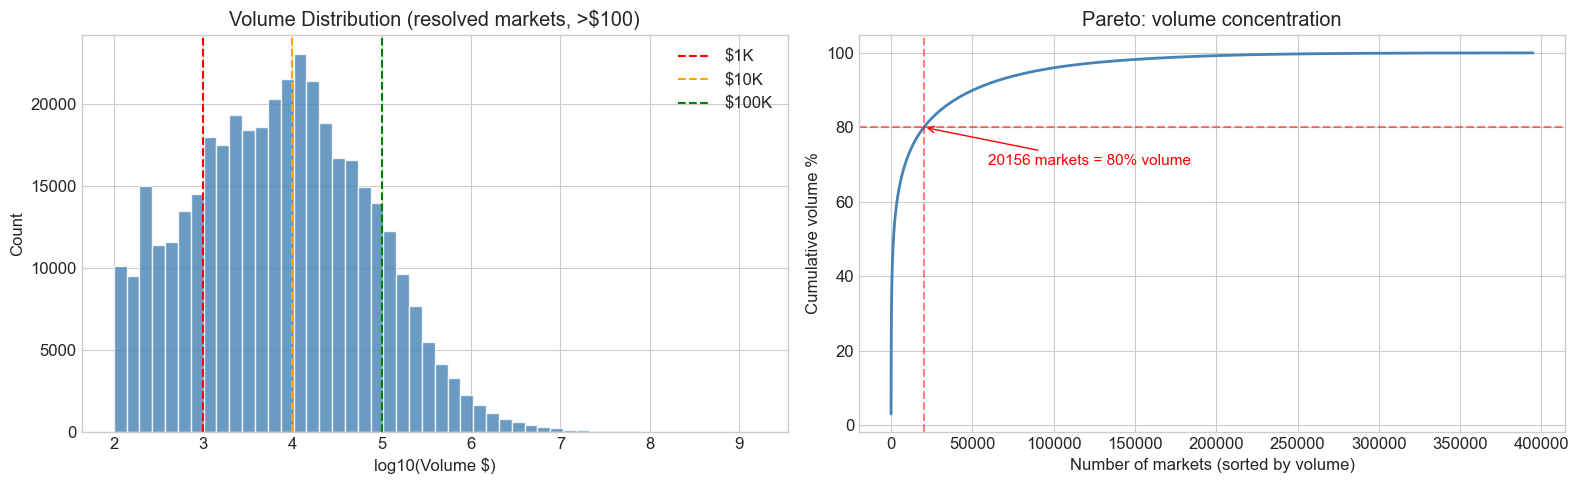

In [4]:
df_active = df[df['_volume'] > 100].copy()
print(f'Markets with volume > $100: {len(df_active):,} ({len(df_active)/len(df)*100:.1f}%)')
print(f'Volume of these markets: ${df_active["_volume"].sum():,.0f} ({df_active["_volume"].sum()/df["_volume"].sum()*100:.1f}% of total)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

log_vol = np.log10(df_active['_volume'])
axes[0].hist(log_vol, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('log10(Volume $)')
axes[0].set_ylabel('Count')
axes[0].set_title('Volume Distribution (resolved markets, >$100)')
axes[0].axvline(np.log10(1000), color='red', ls='--', label='$1K')
axes[0].axvline(np.log10(10000), color='orange', ls='--', label='$10K')
axes[0].axvline(np.log10(100000), color='green', ls='--', label='$100K')
axes[0].legend()

sorted_vol = df_active['_volume'].sort_values(ascending=False).values
cum_share = np.cumsum(sorted_vol) / sorted_vol.sum()
axes[1].plot(range(len(cum_share)), cum_share * 100, color='steelblue', lw=2)
axes[1].set_xlabel('Number of markets (sorted by volume)')
axes[1].set_ylabel('Cumulative volume %')
axes[1].set_title('Pareto: volume concentration')

n80 = np.searchsorted(cum_share, 0.8)
axes[1].axhline(80, color='red', ls='--', alpha=0.5)
axes[1].axvline(n80, color='red', ls='--', alpha=0.5)
axes[1].annotate(f'{n80} markets = 80% volume',
                 xy=(n80, 80), fontsize=11, color='red',
                 xytext=(n80+len(cum_share)*0.1, 70),
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

In [5]:
cal = df_active[
    (df_active['_outcome'].isin(['YES', 'NO'])) &
    (df_active['_price_1m_ago'].between(0.01, 0.99))
].copy()

cal['_yes_won'] = (cal['_outcome'] == 'YES').astype(int)
cal['_pred_price'] = cal['_price_1m_ago']

print(f'Markets for calibration (valid 1m-ago price, vol>$100): {len(cal):,}')
if len(cal) > 0:
    print(f'YES won: {cal["_yes_won"].sum():,} ({cal["_yes_won"].mean()*100:.1f}%)')

if len(cal) < 50:
    print(f'\nToo few markets ({len(cal)}) for reliable calibration.')
    print('Full calibration analysis requires price history data (collecting in background).')

n_bins = min(20, max(5, len(cal) // 20))
bins = np.linspace(0, 1, n_bins + 1)
cal['_prob_bin'] = pd.cut(cal['_pred_price'], bins=bins)

calibration = cal.groupby('_prob_bin', observed=True).agg(
    predicted_prob=('_pred_price', 'mean'),
    actual_freq=('_yes_won', 'mean'),
    count=('_yes_won', 'count'),
    total_volume=('_volume', 'sum'),
).dropna()

print(f'\nCalibration by probability bins:')
print(calibration.to_string())

Markets for calibration (valid 1m-ago price, vol>$100): 5,774
YES won: 2,036 (35.3%)



Calibration by probability bins:
             predicted_prob  actual_freq  count  total_volume
_prob_bin                                                    
(0.0, 0.05]        0.025829     0.019952   1253  3.586332e+08
(0.05, 0.1]        0.070012     0.096661    569  2.461075e+08
(0.1, 0.15]        0.123601     0.132653    392  1.912947e+08
(0.15, 0.2]        0.173338     0.215385    195  1.136564e+08
(0.2, 0.25]        0.226119     0.330508    236  5.589151e+08
(0.25, 0.3]        0.265323     0.199438    356  4.054873e+07
(0.3, 0.35]        0.326961     0.344978    229  4.937852e+07
(0.35, 0.4]        0.377160     0.258687    259  9.752650e+07
(0.4, 0.45]        0.424534     0.389313    262  9.362988e+07
(0.45, 0.5]        0.479891     0.366197    284  5.757687e+07
(0.5, 0.55]        0.518457     0.593284    268  4.040396e+07
(0.55, 0.6]        0.572798     0.720930    129  2.336511e+07
(0.6, 0.65]        0.621404     0.641026     78  2.181927e+07
(0.65, 0.7]        0.676963     0.75

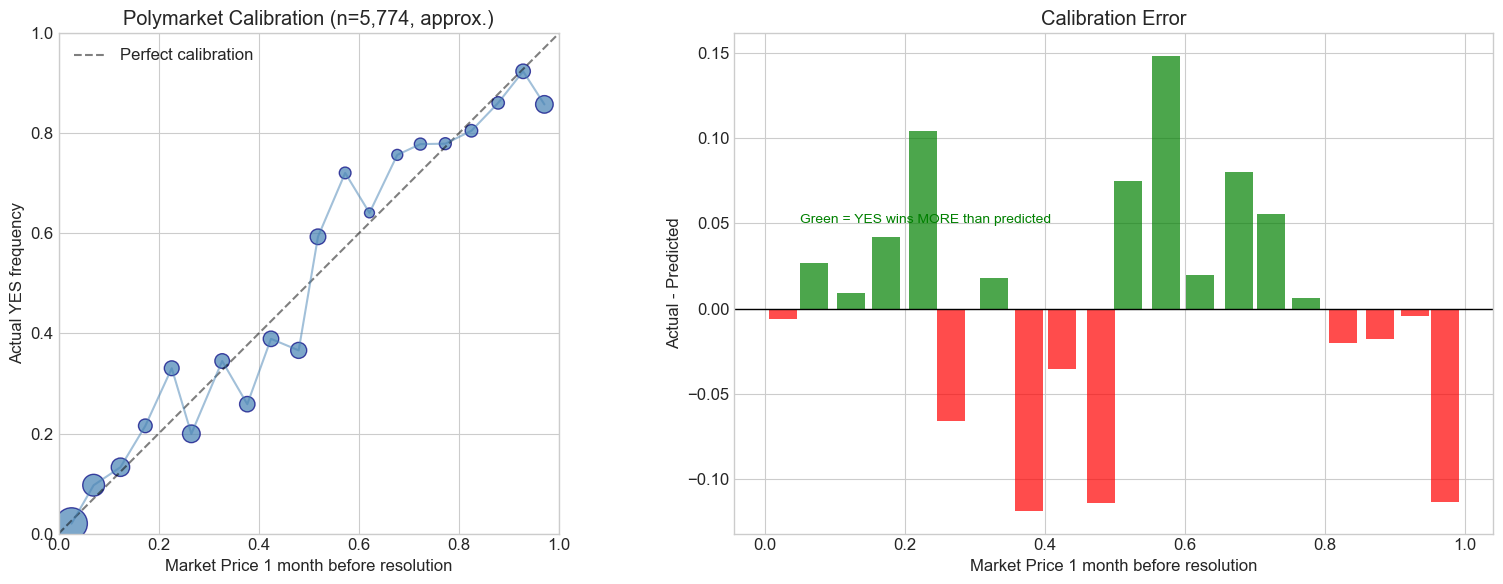

Brier Score (lower=better, 0.25=random): 0.1364


In [6]:
if len(calibration) >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.scatter(
        calibration['predicted_prob'],
        calibration['actual_freq'],
        s=calibration['count'] / calibration['count'].max() * 500 + 20,
        c='steelblue', alpha=0.7, edgecolors='navy', linewidth=1
    )
    ax.plot(calibration['predicted_prob'], calibration['actual_freq'],
            color='steelblue', alpha=0.5)
    ax.set_xlabel('Market Price 1 month before resolution')
    ax.set_ylabel('Actual YES frequency')
    ax.set_title(f'Polymarket Calibration (n={len(cal):,}, approx.)')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(); ax.set_aspect('equal')

    ax2 = axes[1]
    deviation = calibration['actual_freq'] - calibration['predicted_prob']
    colors = ['green' if d > 0 else 'red' for d in deviation]
    ax2.bar(calibration['predicted_prob'], deviation,
            width=1.0/len(calibration)*0.8, color=colors, alpha=0.7)
    ax2.axhline(0, color='black', lw=1)
    ax2.set_xlabel('Market Price 1 month before resolution')
    ax2.set_ylabel('Actual - Predicted')
    ax2.set_title('Calibration Error')
    ax2.annotate('Green = YES wins MORE than predicted', xy=(0.05, 0.05),
                 fontsize=10, color='green', transform=ax2.transAxes)
    ax2.annotate('Red = YES wins LESS than predicted', xy=(0.05, 0.90),
                 fontsize=10, color='red', transform=ax2.transAxes)

    plt.tight_layout()
    plt.show()

    brier = np.mean((cal['_pred_price'] - cal['_yes_won']) ** 2)
    print(f'Brier Score (lower=better, 0.25=random): {brier:.4f}')
else:
    print('Not enough bins for calibration plot. Need price history data.')

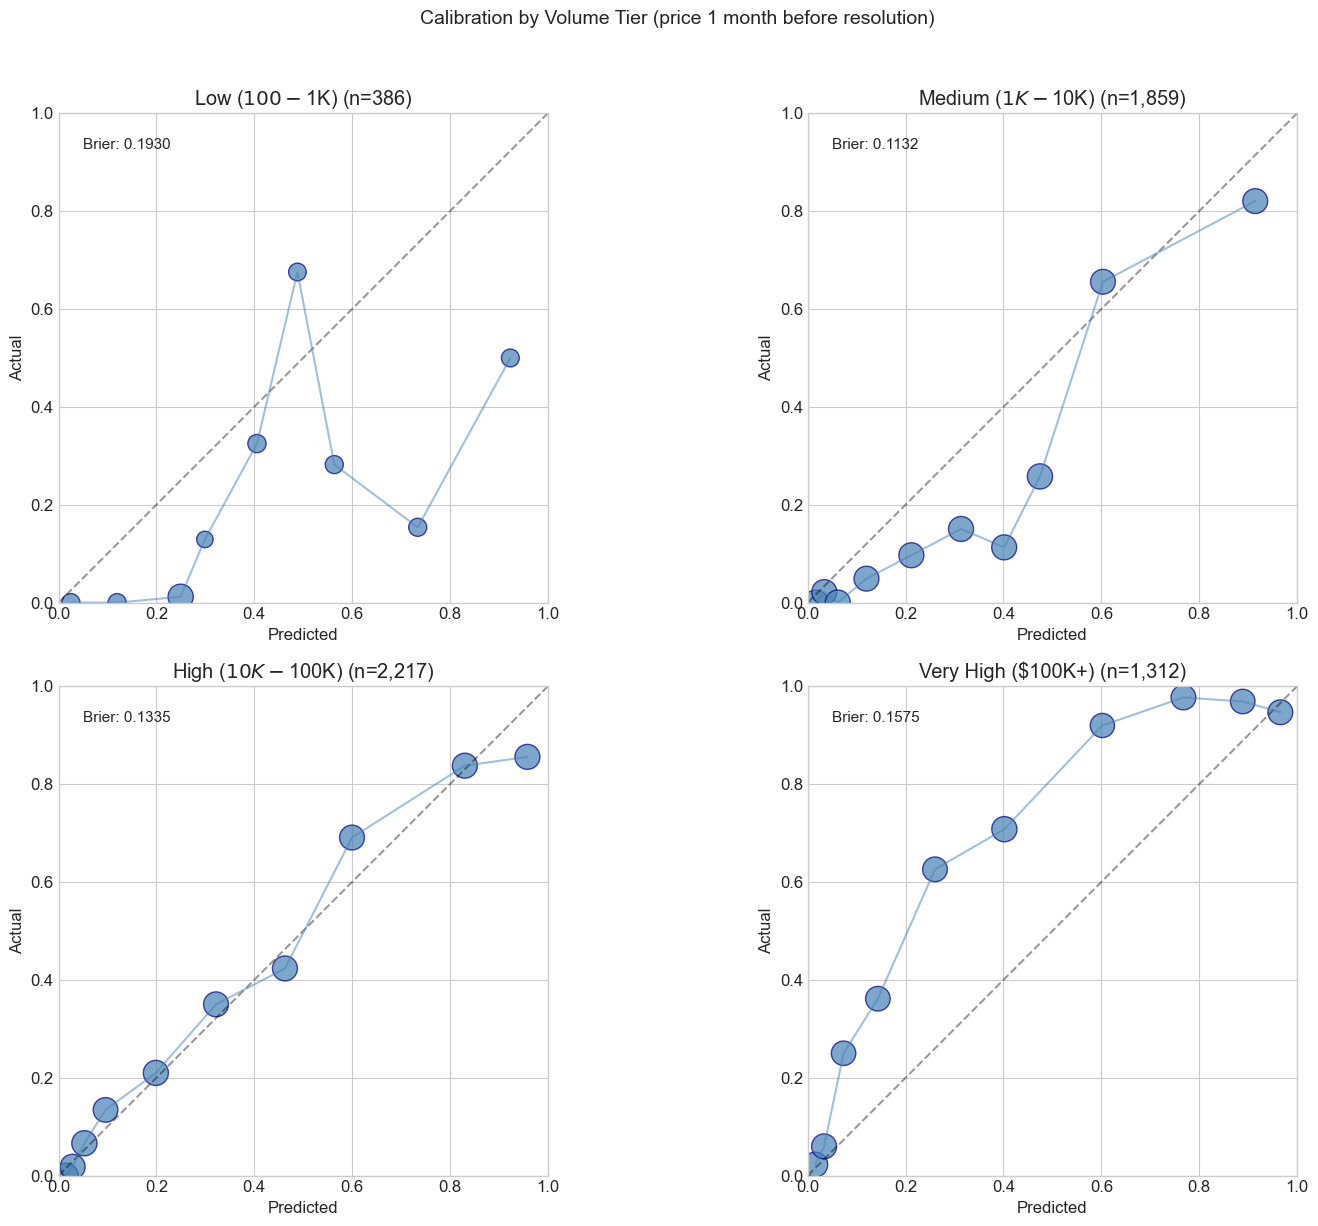

In [7]:
if len(cal) < 50:
    print(f'Only {len(cal)} markets with reconstructed prices — skipping volume tier breakdown.')
    print('Full analysis requires price history data.')
else:
    vol_tiers = {
        'Low ($100-$1K)': (100, 1000),
        'Medium ($1K-$10K)': (1000, 10000),
        'High ($10K-$100K)': (10000, 100000),
        'Very High ($100K+)': (100000, float('inf')),
    }

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, (tier_name, (vmin, vmax)) in enumerate(vol_tiers.items()):
        tier = cal[(cal['_volume'] >= vmin) & (cal['_volume'] < vmax)]
        if len(tier) < 20:
            axes[i].text(0.5, 0.5, f'{tier_name}\nNot enough data ({len(tier)})',
                         ha='center', va='center', transform=axes[i].transAxes)
            continue

        n_bins = min(10, max(5, len(tier) // 30))
        tier_bins = pd.qcut(tier['_pred_price'], q=n_bins, duplicates='drop')

        tier_cal = tier.groupby(tier_bins, observed=True).agg(
            pred=('_pred_price', 'mean'),
            actual=('_yes_won', 'mean'),
            n=('_yes_won', 'count')
        )

        ax = axes[i]
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
        ax.scatter(tier_cal['pred'], tier_cal['actual'],
                  s=tier_cal['n'] / tier_cal['n'].max() * 300 + 30,
                  c='steelblue', alpha=0.7, edgecolors='navy')
        ax.plot(tier_cal['pred'], tier_cal['actual'], color='steelblue', alpha=0.5)
        ax.set_title(f'{tier_name} (n={len(tier):,})')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')

        brier_tier = np.mean((tier['_pred_price'] - tier['_yes_won']) ** 2)
        ax.text(0.05, 0.95, f'Brier: {brier_tier:.4f}', transform=ax.transAxes,
                fontsize=11, verticalalignment='top')

    plt.suptitle('Calibration by Volume Tier (price 1 month before resolution)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

Markets with timing data: 389,964

Lifetime stats (days):
count    389964.000000
mean          8.159019
std          24.109070
min           0.003919
25%           0.998080
50%           1.901658
75%           6.608680
max         364.804870
Name: _lifetime_days, dtype: float64


/var/folders/qw/dzzvs80x2x5_74jbksl4n2h40000gn/T/ipykernel_2421/2653862630.py:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  timing['_closed_month'] = timing['_closedTime'].dt.to_period('M')


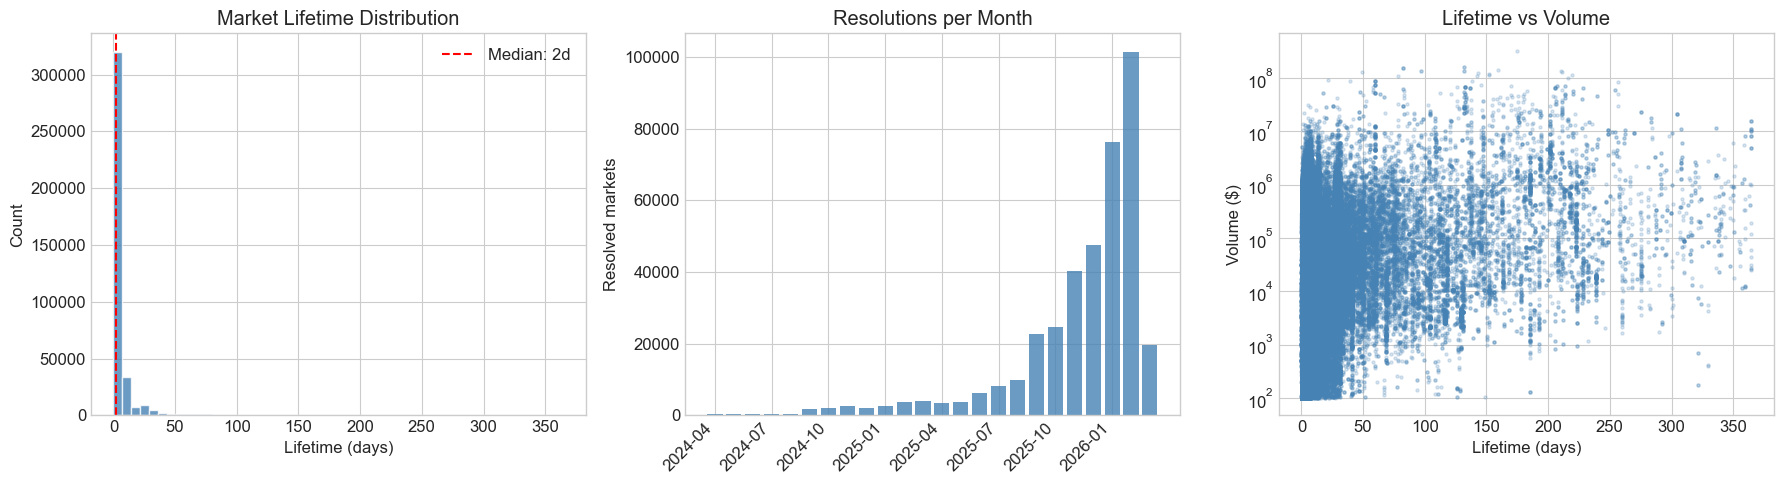

In [8]:
timing = df_active.dropna(subset=['_startDate', '_closedTime']).copy()
timing['_lifetime_days'] = (timing['_closedTime'] - timing['_startDate']).dt.total_seconds() / 86400

timing = timing[(timing['_lifetime_days'] > 0) & (timing['_lifetime_days'] < 365)]

print(f'Markets with timing data: {len(timing):,}')
print(f'\nLifetime stats (days):')
print(timing['_lifetime_days'].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(timing['_lifetime_days'], bins=50, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Lifetime (days)')
axes[0].set_ylabel('Count')
axes[0].set_title('Market Lifetime Distribution')
axes[0].axvline(timing['_lifetime_days'].median(), color='red', ls='--',
                label=f'Median: {timing["_lifetime_days"].median():.0f}d')
axes[0].legend()

timing['_closed_month'] = timing['_closedTime'].dt.to_period('M')
monthly = timing.groupby('_closed_month').size()
monthly.index = monthly.index.astype(str)
if len(monthly) > 24:
    monthly = monthly.tail(24)
axes[1].bar(range(len(monthly)), monthly.values, color='steelblue', alpha=0.8)
axes[1].set_xticks(range(0, len(monthly), max(1, len(monthly)//8)))
axes[1].set_xticklabels(
    [monthly.index[i] for i in range(0, len(monthly), max(1, len(monthly)//8))],
    rotation=45, ha='right'
)
axes[1].set_ylabel('Resolved markets')
axes[1].set_title('Resolutions per Month')

axes[2].scatter(timing['_lifetime_days'], timing['_volume'],
                alpha=0.2, s=5, color='steelblue')
axes[2].set_xlabel('Lifetime (days)')
axes[2].set_ylabel('Volume ($)')
axes[2].set_title('Lifetime vs Volume')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

In [9]:
if len(cal) < 30:
    print(f'Only {len(cal)} markets — P&L simulation needs price history data.')
    print('Skipping detailed simulation, will revisit with full price data.')
    strategies = {}
else:
    sim = cal.copy()
    p = sim['_pred_price'].values
    won_yes = sim['_yes_won'].values.astype(bool)

    strategies = {}

    strategies['Always YES'] = np.where(won_yes, 1 - p, -p)

    strategies['Always NO'] = np.where(~won_yes, p, -(1 - p))

    strategies['Contrarian'] = np.where(
        p < 0.5,
        np.where(won_yes, 1 - p, -p),
        np.where(~won_yes, p, -(1 - p))
    )

    pnl_v_yes = np.where(won_yes, 1 - p, -p)
    pnl_v_yes[p >= 0.4] = 0
    strategies['Value YES (<0.4)'] = pnl_v_yes

    pnl_v_no = np.where(~won_yes, p, -(1 - p))
    pnl_v_no[p <= 0.6] = 0
    strategies['Value NO (>0.6)'] = pnl_v_no

    print(f'Simulating on {len(cal):,} markets (price = 1 month before resolution)')
    print(f'\n{"Strategy":<25} {"Trades":>8} {"Win Rate":>10} {"Total PnL":>12} {"Avg PnL":>10} {"Sharpe":>8}')
    print('-' * 80)
    for name, pnl in strategies.items():
        active = pnl[pnl != 0]
        trades = len(active)
        wins = np.sum(active > 0)
        wr = wins / trades if trades > 0 else 0
        total = active.sum()
        avg = active.mean() if trades > 0 else 0
        sharpe = active.mean() / active.std() if trades > 0 and active.std() > 0 else 0
        print(f'{name:<25} {trades:>8,} {wr:>9.1%} {total:>11,.1f}$ {avg:>9.4f}$ {sharpe:>7.3f}')

Simulating on 5,774 markets (price = 1 month before resolution)

Strategy                    Trades   Win Rate    Total PnL    Avg PnL   Sharpe
--------------------------------------------------------------------------------
Always YES                   5,774     35.3%       -36.0$   -0.0062$  -0.017
Always NO                    5,774     64.7%        36.0$    0.0062$   0.017
Contrarian                   5,774     18.2%       -58.7$   -0.0102$  -0.028
Value YES (<0.4)             3,488     13.4%        -5.4$   -0.0016$  -0.005
Value NO (>0.6)              1,342     17.4%        27.9$    0.0208$   0.055


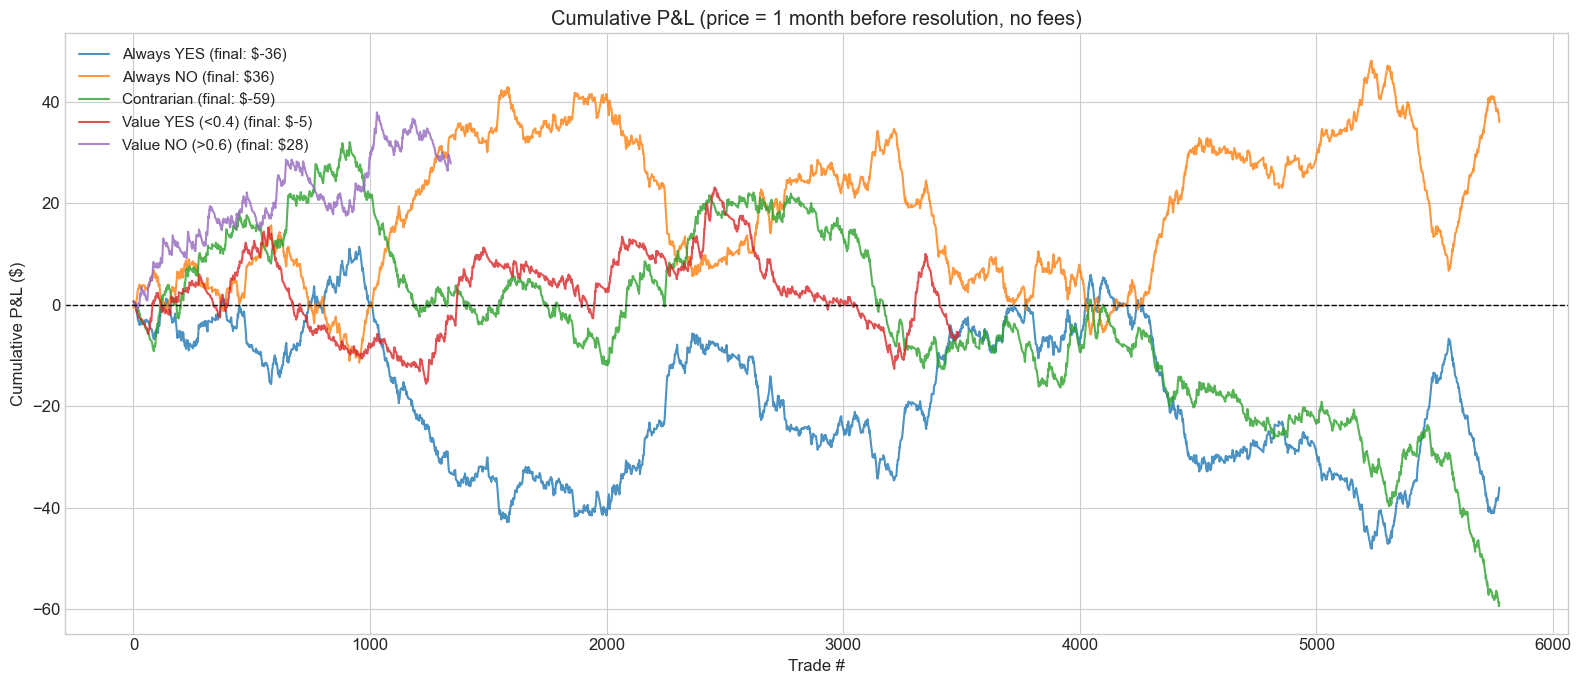

In [10]:
if strategies:
    fig, ax = plt.subplots(figsize=(16, 7))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    for (name, pnl), color in zip(strategies.items(), colors):
        active_pnl = pnl[pnl != 0]
        if len(active_pnl) > 0:
            cum = np.cumsum(active_pnl)
            ax.plot(cum, label=f'{name} (final: ${cum[-1]:,.0f})', color=color, alpha=0.8)
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Cumulative P&L ($)')
    ax.set_title('Cumulative P&L (price = 1 month before resolution, no fees)')
    ax.legend(loc='best', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('No strategies to plot — waiting for price history data.')

Strategy                    PnL (no fee)       Fees   PnL (w/ fee)   Fee Impact
--------------------------------------------------------------------------------
Always YES                        -36.0$       8.7$         -44.8$       24.2%
Always NO                          36.0$       9.0$          27.1$       24.8%
Contrarian                        -58.7$       7.9$         -66.5$       13.4%
Value YES (<0.4)                   -5.4$       3.1$          -8.5$       56.8%
Value NO (>0.6)                    27.9$       1.3$          26.5$        4.7%


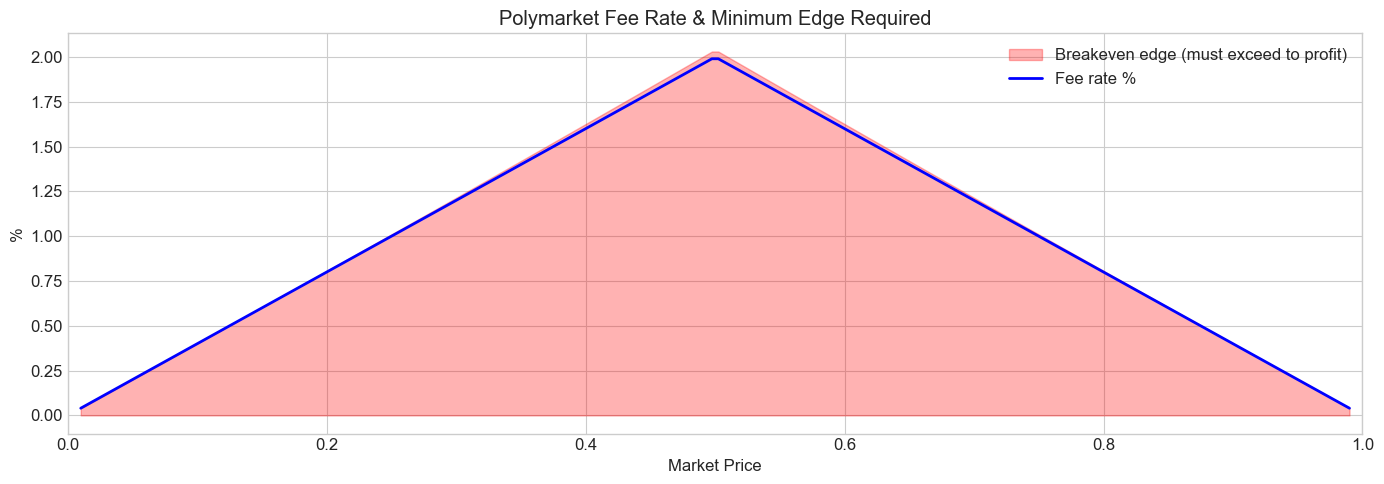


Key insight: max fee is ~2% at price=0.50
At extremes (price near 0 or 1), fees are negligible
→ Resolution convergence strategy has low fee drag


In [11]:
def polymarket_fee_rate(price):
    """Approximate Polymarket fee rate based on price."""
    return 2 * np.minimum(price, 1 - price) * 0.02

if strategies:
    p_arr = cal['_pred_price'].values
    print(f'{"Strategy":<25} {"PnL (no fee)":>14} {"Fees":>10} {"PnL (w/ fee)":>14} {"Fee Impact":>12}')
    print('-' * 80)
    for name, pnl in strategies.items():
        active_mask = pnl != 0
        if not active_mask.any(): continue
        profit = np.maximum(pnl, 0)
        fee_rates = polymarket_fee_rate(p_arr)
        fees = profit * fee_rates
        fees[~active_mask] = 0
        total_before = pnl[active_mask].sum()
        total_fees = fees.sum()
        total_after = (pnl - fees)[active_mask].sum()
        pct = total_fees / abs(total_before) * 100 if total_before != 0 else 0
        print(f'{name:<25} {total_before:>13,.1f}$ {total_fees:>9,.1f}$ {total_after:>13,.1f}$ {pct:>10.1f}%')

fig, ax = plt.subplots(figsize=(14, 5))
prices = np.linspace(0.01, 0.99, 200)
fee_rates = polymarket_fee_rate(prices)
breakeven_edge = fee_rates / (1 - fee_rates + 1e-10)

ax.fill_between(prices, breakeven_edge * 100, alpha=0.3, color='red',
                label='Breakeven edge (must exceed to profit)')
ax.plot(prices, fee_rates * 100, color='blue', lw=2, label='Fee rate %')
ax.set_xlabel('Market Price')
ax.set_ylabel('%')
ax.set_title('Polymarket Fee Rate & Minimum Edge Required')
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print('\nKey insight: max fee is ~2% at price=0.50')
print('At extremes (price near 0 or 1), fees are negligible')
print('→ Resolution convergence strategy has low fee drag')

Events with tags: 143,581 / 143,582



Top 15 categories by volume (resolved markets with vol>$100):
                   count  yes_rate  total_volume    avg_volume
_category                                                     
Sports            112304  0.416325  1.415690e+10  1.260587e+05
Trump               2394  0.343358  3.998501e+09  1.670218e+06
Politics            4276  0.269645  3.390271e+09  7.928604e+05
Up or Down         68110  0.497666  2.917299e+09  4.283217e+04
Crypto             20128  0.457422  1.956934e+09  9.722448e+04
Bitcoin             7023  0.312687  1.829468e+09  2.604967e+05
Global Elections     671  0.128167  1.737479e+09  2.589387e+06
Culture             5306  0.153788  1.406590e+09  2.650943e+05
Fed Rates             73  0.246575  1.349263e+09  1.848306e+07
Esports            39118  0.478757  1.075029e+09  2.748169e+04
All                 6361  0.455117  9.572984e+08  1.504950e+05
Geopolitics          677  0.268833  9.422579e+08  1.391814e+06
Soccer              1536  0.329427  9.202604e+08  5.991

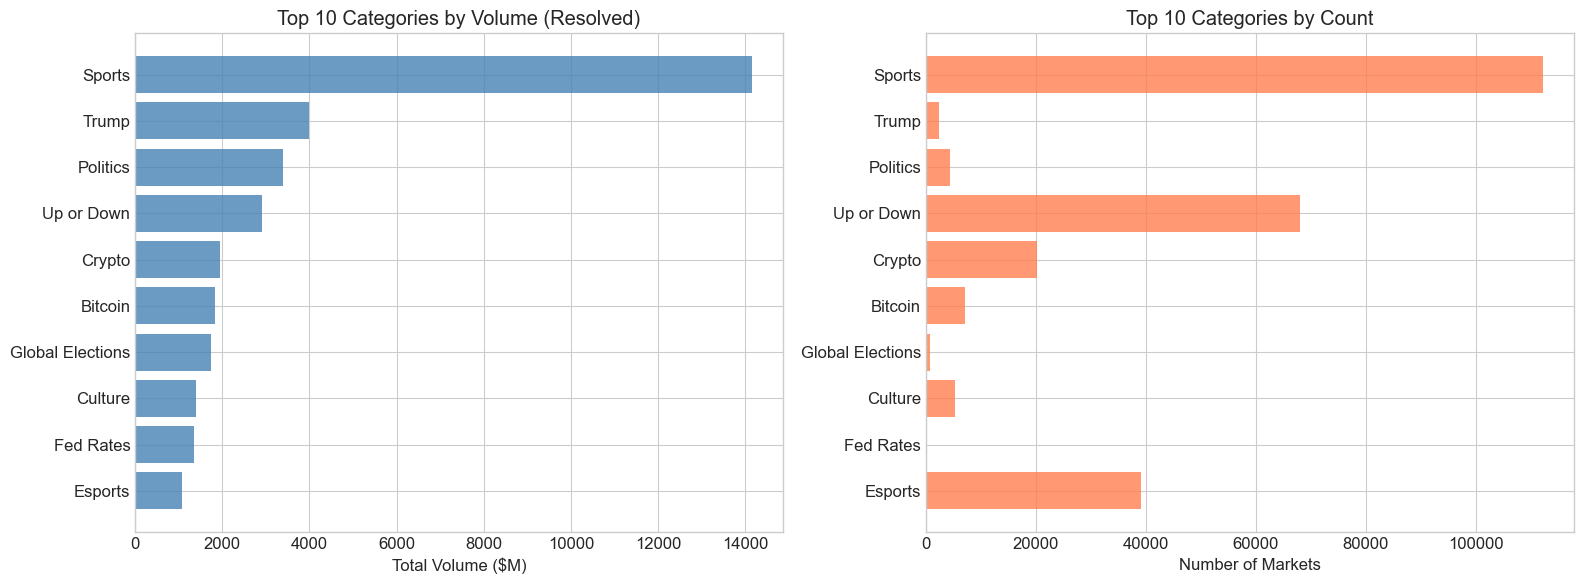


YES win rate by category (top 10):
  Sports              : 41.6% YES wins (112,304.0 markets)
  Trump               : 34.3% YES wins (2,394.0 markets)
  Politics            : 27.0% YES wins (4,276.0 markets)
  Up or Down          : 49.8% YES wins (68,110.0 markets)
  Crypto              : 45.7% YES wins (20,128.0 markets)
  Bitcoin             : 31.3% YES wins (7,023.0 markets)
  Global Elections    : 12.8% YES wins (671.0 markets)
  Culture             : 15.4% YES wins (5,306.0 markets)
  Fed Rates           : 24.7% YES wins (73.0 markets)
  Esports             : 47.9% YES wins (39,118.0 markets)


In [12]:
with open(DATA_DIR / 'events_resolved_20260305_163321.json') as f:
    events_resolved = json.load(f)

event_tags = {}
for ev in events_resolved:
    eid = str(ev.get('id', ''))
    tags = ev.get('tags', [])
    if isinstance(tags, list) and tags:
        labels = [t['label'] if isinstance(t, dict) else str(t) for t in tags]
        event_tags[eid] = labels
    else:
        event_tags[eid] = ['Unknown']

print(f'Events with tags: {sum(1 for v in event_tags.values() if v != ["Unknown"]):,} / {len(event_tags):,}')

cat_df = df_active[df_active['_outcome'].isin(['YES', 'NO'])].copy()
cat_df['_yes_won'] = (cat_df['_outcome'] == 'YES').astype(int)

cat_df['_tags'] = cat_df['_event_id'].astype(str).map(event_tags).apply(
    lambda x: x if isinstance(x, list) else ['Unknown']
)
cat_df['_category'] = cat_df['_tags'].apply(lambda x: x[0] if x else 'Unknown')

cat_stats = cat_df.groupby('_category').agg(
    count=('_yes_won', 'count'),
    yes_rate=('_yes_won', 'mean'),
    total_volume=('_volume', 'sum'),
    avg_volume=('_volume', 'mean'),
).sort_values('total_volume', ascending=False)

print(f'\nTop 15 categories by volume (resolved markets with vol>$100):')
print(cat_stats.head(15).to_string())

top_cats = cat_stats.head(10)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(range(len(top_cats)), top_cats['total_volume'] / 1e6, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(top_cats)))
axes[0].set_yticklabels(top_cats.index)
axes[0].set_xlabel('Total Volume ($M)')
axes[0].set_title('Top 10 Categories by Volume (Resolved)')
axes[0].invert_yaxis()

axes[1].barh(range(len(top_cats)), top_cats['count'], color='coral', alpha=0.8)
axes[1].set_yticks(range(len(top_cats)))
axes[1].set_yticklabels(top_cats.index)
axes[1].set_xlabel('Number of Markets')
axes[1].set_title('Top 10 Categories by Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f'\nYES win rate by category (top 10):')
for cat in top_cats.index:
    row = top_cats.loc[cat]
    print(f'  {cat:20s}: {row["yes_rate"]:.1%} YES wins ({row["count"]:,} markets)')

NegRisk resolved markets: 84,566
Volume: $26,777,115,413
Group-related columns: ['groupItemTitle', 'groupItemThreshold', 'marketGroup', 'groupItemRange']

Outcome distribution (negRisk):
_outcome
NO            70226
YES           14329
unresolved       11
Name: count, dtype: int64


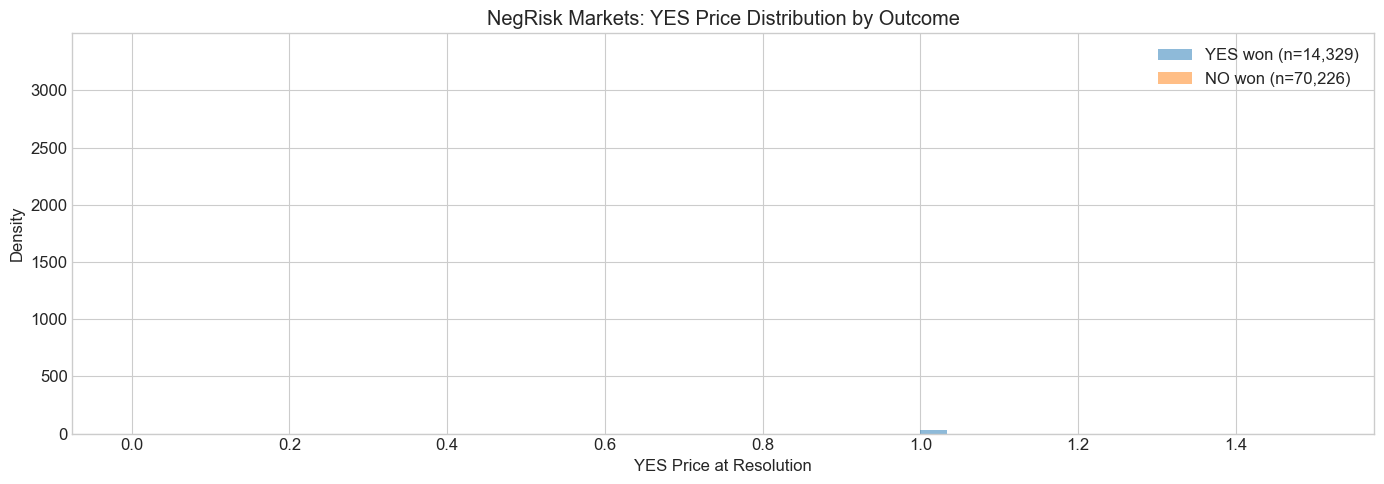

In [13]:
neg_risk = df_active[df_active.get('negRisk', pd.Series(dtype=bool)) == True].copy()

if len(neg_risk) > 0:
    print(f'NegRisk resolved markets: {len(neg_risk):,}')
    print(f'Volume: ${neg_risk["_volume"].sum():,.0f}')

    group_cols = [c for c in neg_risk.columns if 'group' in c.lower()]
    print(f'Group-related columns: {group_cols}')

    print(f'\nOutcome distribution (negRisk):')
    print(neg_risk['_outcome'].value_counts())

    fig, ax = plt.subplots(figsize=(14, 5))
    for outcome in ['YES', 'NO']:
        subset = neg_risk[neg_risk['_outcome'] == outcome]
        if len(subset) > 10:
            ax.hist(subset['_yes_price'], bins=30, alpha=0.5,
                    label=f'{outcome} won (n={len(subset):,})', density=True)
    ax.set_xlabel('YES Price at Resolution')
    ax.set_ylabel('Density')
    ax.set_title('NegRisk Markets: YES Price Distribution by Outcome')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No NegRisk markets found in resolved data')